
🔹 Обработка модели: Linear Regression



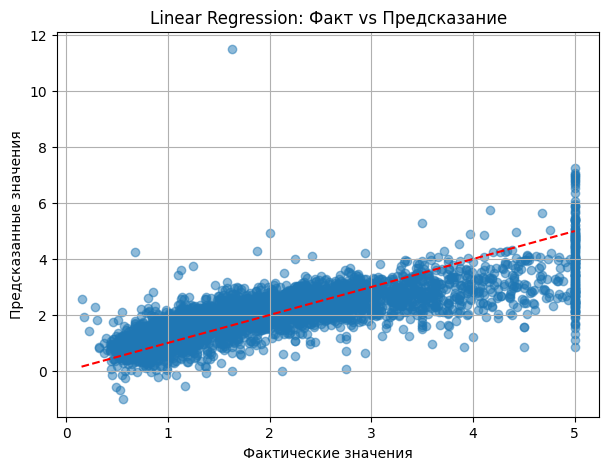

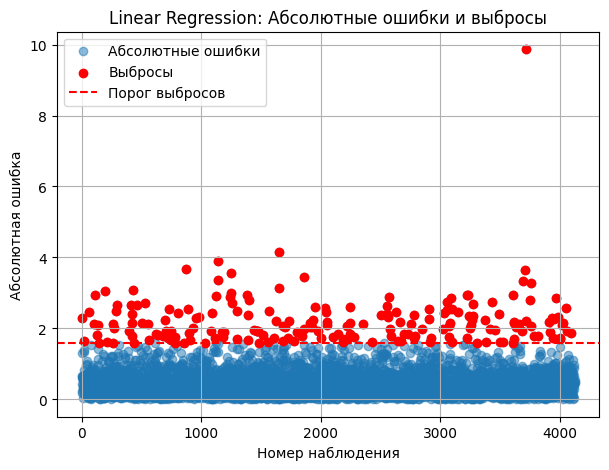

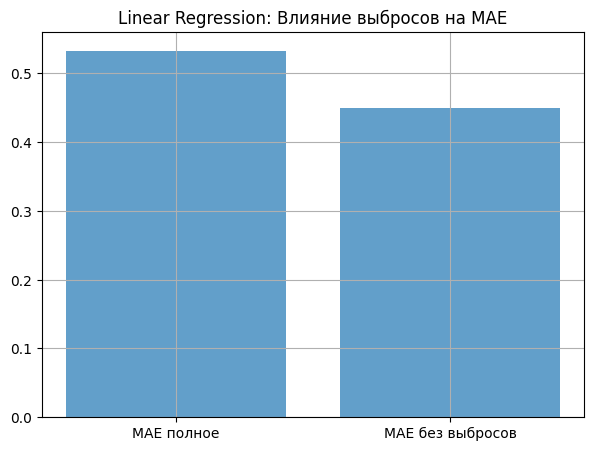

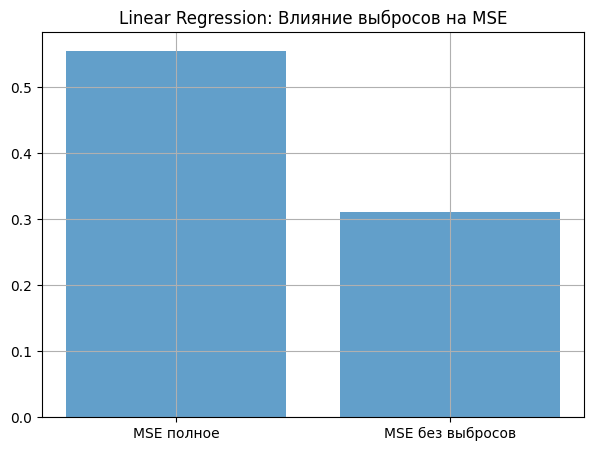


🔹 Обработка модели: Random Forest



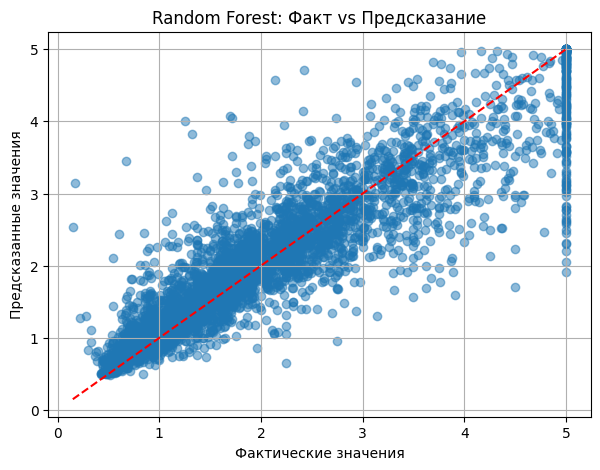

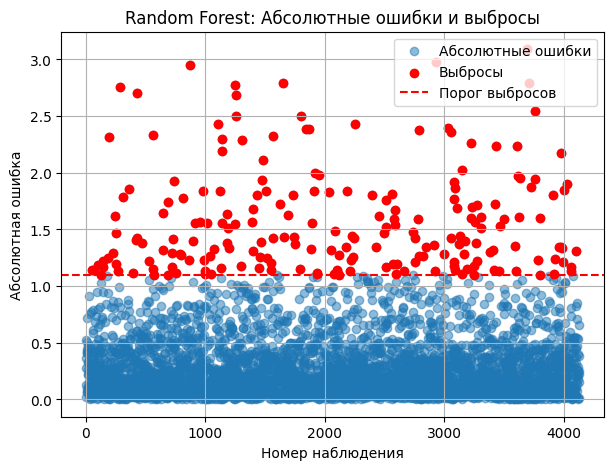

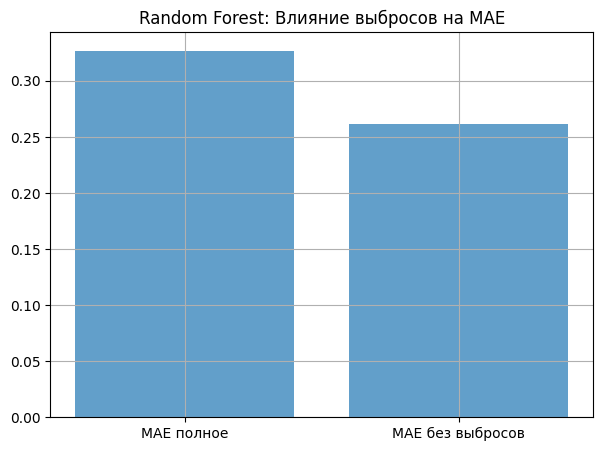

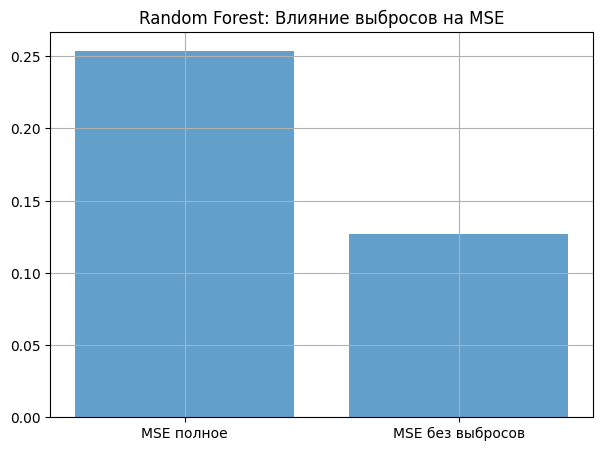


🔹 Обработка модели: Gradient Boosting



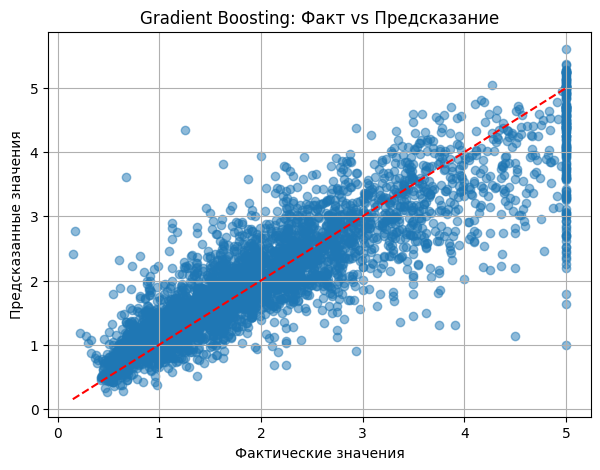

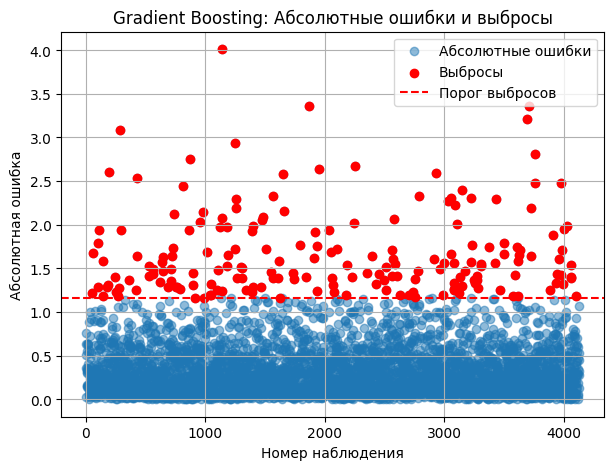

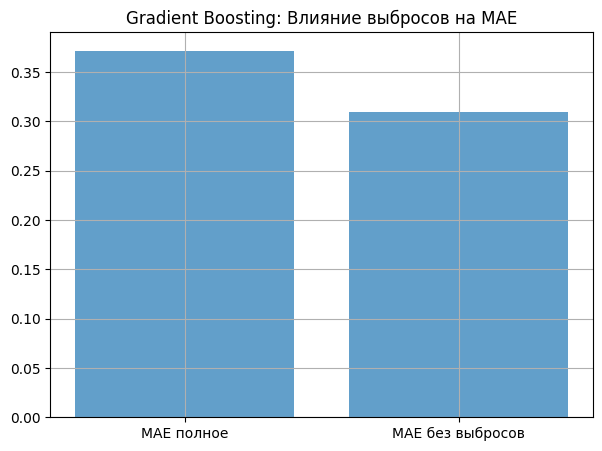

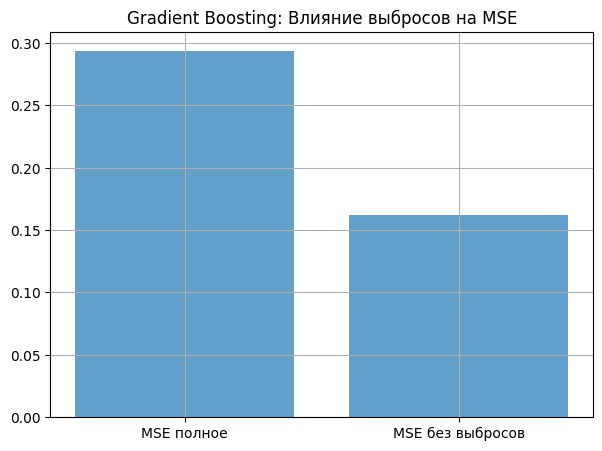


===== Итоговые результаты =====

               Model       MAE       MSE
0  Linear Regression  0.533200  0.555892
1      Random Forest  0.326812  0.253976
2  Gradient Boosting  0.371643  0.293997


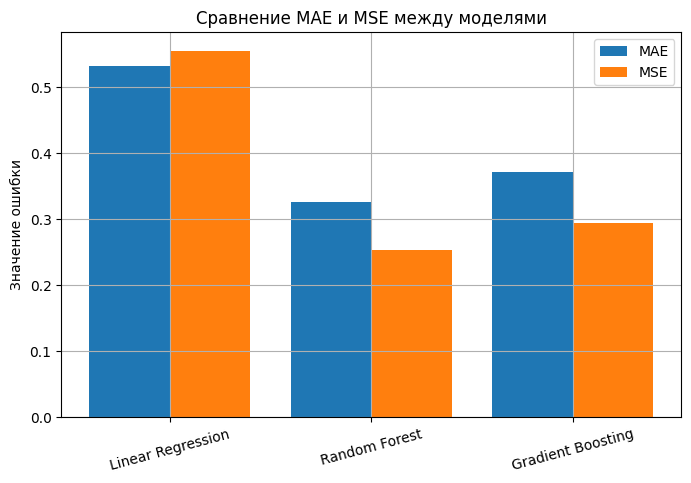

In [ ]:
# ====== 0. ИМПОРТЫ ======

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


# ====== 1. ЗАГРУЗКА ДАННЫХ ======

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")


# ====== 2. TRAIN / TEST SPLIT ======

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ====== 3. МОДЕЛИ ======

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}


# ====== 4. ОБРАБОТКА МОДЕЛЕЙ И ВИЗУАЛИЗАЦИИ ======

all_results = {}

for name, model in models.items():
    print(f"\n🔹 Обработка модели: {name}\n")

    # ----- 1. Обучение + предсказание -----
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Метрики
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    all_results[name] = {"y_pred": y_pred, "MAE": mae, "MSE": mse}

    # ----- 2. График: Факт vs Предсказание -----
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Фактические значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"{name}: Факт vs Предсказание")
    plt.grid(True)
    plt.show()

    # ----- 3. Абсолютные ошибки + выбросы -----
    errors = np.abs(y_test - y_pred)
    err_mean = errors.mean()
    err_std = errors.std()
    threshold = err_mean + 2 * err_std
    outliers = errors > threshold

    plt.figure(figsize=(7, 5))
    plt.scatter(range(len(errors)), errors, alpha=0.5, label="Абсолютные ошибки")
    plt.scatter(np.where(outliers)[0], errors[outliers],
                color='red', label='Выбросы')
    plt.axhline(threshold, color='red', linestyle='--', label='Порог выбросов')
    plt.xlabel("Номер наблюдения")
    plt.ylabel("Абсолютная ошибка")
    plt.title(f"{name}: Абсолютные ошибки и выбросы")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----- 4. Влияние выбросов -----
    y_pred_clean = y_pred[~outliers]
    y_test_clean = y_test[~outliers]

    mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)
    mse_clean = mean_squared_error(y_test_clean, y_pred_clean)

    # MAE — влияние выбросов
    plt.figure(figsize=(7, 5))
    plt.bar(["MAE полное", "MAE без выбросов"],
            [mae, mae_clean], alpha=0.7)
    plt.title(f"{name}: Влияние выбросов на MAE")
    plt.grid(True)
    plt.show()

    # MSE — влияние выбросов
    plt.figure(figsize=(7, 5))
    plt.bar(["MSE полное", "MSE без выбросов"],
            [mse, mse_clean], alpha=0.7)
    plt.title(f"{name}: Влияние выбросов на MSE")
    plt.grid(True)
    plt.show()


# ====== 5. СРАВНЕНИЕ МОДЕЛЕЙ (общая таблица) ======

results_df = pd.DataFrame([
    [name, all_results[name]["MAE"], all_results[name]["MSE"]]
    for name in all_results
], columns=["Model", "MAE", "MSE"])

print("\n===== Итоговые результаты =====\n")
print(results_df)

# ----- График сравнения -----

plt.figure(figsize=(8, 5))
x = np.arange(len(results_df))

plt.bar(x - 0.2, results_df["MAE"], width=0.4, label="MAE")
plt.bar(x + 0.2, results_df["MSE"], width=0.4, label="MSE")

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylabel("Значение ошибки")
plt.title("Сравнение MAE и MSE между моделями")
plt.legend()
plt.grid(True)
plt.show()
